In [1]:
import pymongo
from pymongo import MongoClient
import matplotlib.pyplot as plt
import numpy as np

client = MongoClient('localhost', 5001)

db = client.flask_db
annotation = db.annotation

valueToLabel = {
    1: "Idea Generation", 2: "Idea Organization", 3: "Discourse Planning",
    4: "Drafting", 5: "Lexical Chaining", 6: "Object Insertion",
    7: "Semantic", 8: "Syntactic", 9: "Lexical",
    10: "Structural", 11: "Visual", 12: "Quantitative",
    13: "Feedback", 0: "No Label", 14: "Artifact", 15: "Command Insertion",
    16: "Citation", 17: "Custom label"
}

all_labels = [
    "Idea Generation", "Idea Organization", "Discourse Planning",
    "Drafting", "Lexical Chaining", "Object Insertion",
    "Semantic", "Syntactic", "Lexical",
    "Structural", "Visual", "Quantitative",
    "Feedback", "No Label", "Artifact", "Command Insertion",
    "Citation", "Custom Label"
]

table_size = len(valueToLabel)

project_id = "656a440644dec9f71f2dee44"

steps = [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1200, 1257]

schedule = [["lee03533@umn.edu", "chau0139@umn.edu", "rossvolkov@gmail.com"],
            ["lee03533@umn.edu", "chau0139@umn.edu", "wang9257@umn.edu"],
            ["lee03533@umn.edu", "sam", "rossvolkov@gmail.com", ],
            ["lee03533@umn.edu", "chau0139@umn.edu", "wang9257@umn.edu"],
            ["lee03533@umn.edu", "chau0139@umn.edu", "rossvolkov@gmail.com"],
            ["lee03533@umn.edu", "sam", "wang9257@umn.edu"],
            ["lee03533@umn.edu", "chau0139@umn.edu", "rossvolkov@gmail.com"],
            ["lee03533@umn.edu", "sam", "wang9257@umn.edu"],
            ["lee03533@umn.edu", "chau0139@umn.edu", "rossvolkov@gmail.com"],
            ["Nazar101@umn.edu", "sam", "wang9257@umn.edu"],
            ]


def draw_bitmap(labels):
    bitmap = []
    for i in range(len(labels)):
        row = [0] * (table_size)
        for idx in labels[i]:
            try:
                temp = all_labels.index(idx)
                row[temp] = 1
            except ValueError:
                row[17] = 1
        bitmap.append(row)
    return bitmap


total_span = []
consensus_span_count = {}

In [2]:
import pandas as pd

activity = client.dataset_db.data

query = {'project_id': project_id}

cursor = activity.find(query).sort("index", pymongo.ASCENDING)

activity_df = pd.DataFrame(list(cursor))

In [ ]:
start_Idx = 0
for i in range(len(schedule)):

    end_Idx = start_Idx + steps[i]

    print(f"---------- {start_Idx} to {end_Idx} ----------")

    print(schedule[i][0], ",", schedule[i][1], ",", schedule[i][2])

    a1 = annotation.find_one({"annotatorEmail": schedule[i][0]})
    a2 = annotation.find_one({"annotatorEmail": schedule[i][1]})
    a3 = annotation.find_one({"annotatorEmail": schedule[i][2]})

    labels1 = a1[project_id]["filledArray"][start_Idx:end_Idx]
    labels2 = a2[project_id]["filledArray"][start_Idx:end_Idx]
    labels3 = a3[project_id]["filledArray"][start_Idx:end_Idx]

    bm1 = draw_bitmap(labels1)
    bm2 = draw_bitmap(labels2)
    bm3 = draw_bitmap(labels3)
    bms = [bm1, bm2, bm3]

    # gold_std: the array that will be used for indexing (see loop below)
    gold_std = bms[0]
    # same_arr: 0 means no consensus,
    # any other value (see valueToLabel above) means label that all three annotators agreed on
    same_arr = [0] * len(gold_std)

    # loop through the annotation data made by three annotators.
    # If all of them are the same on edit at index i, we update the label in the same_arr[i]
    for i in range(len(gold_std)):
        for j in range(len(gold_std[i])):
            if gold_std[i][j] == 1 and bms[1][i][j] == 1 and bms[2][i][j] == 1:
                same_arr[i] = j

    skip_arr = [0, 14]  # skip_arr: we ignore labels that are artifact or have no consensus
    span_arr = []   # span_arr: human-readable array that store the consensus edits span

    # Calculate the beginning and ending of each label in the array.
    # if next label does not equal to current label, we calculate the beginning and ending of current label.
    # e.g.input: [1, 1, 1, 2, 2, 2, 1, 3, 3, 3]
    # output: [["ideaGeneration", 0, 2], ["ideaOrganization", 3, 5], ["ideaGeneration", 6, 6], ["discoursePlanning", 7, 9]]
    prev_idx = 0
    for k in range(len(same_arr) - 1):
        if same_arr[k] in skip_arr:
            prev_idx = k + 1
            continue
        if same_arr[k] != same_arr[k + 1]:
            span_arr.append([valueToLabel[same_arr[k]], start_Idx + prev_idx, start_Idx + k])
            prev_idx = k + 1

    if same_arr[k+1] not in skip_arr:
            span_arr.append([valueToLabel[same_arr[k]], start_Idx + prev_idx, start_Idx + k + 1])

    print(span_arr)
    total_span.extend(span_arr)
    
    start_Idx = end_Idx

C:\Users\12896\AppData\Local\Temp\ipykernel_84428\1594072209.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis', len(consensus_span_count))


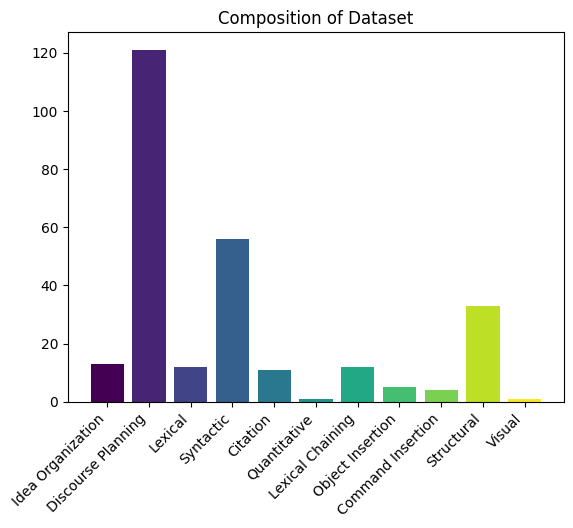

In [4]:
# this for-loop count number of data points in dataset
for each in total_span:
    label = each[0]
    if label in consensus_span_count:
        consensus_span_count[label] += 1
    else:
        consensus_span_count[label] = 1

names = list(consensus_span_count.keys())
values = list(consensus_span_count.values())

# Use a colormap
cmap = plt.cm.get_cmap('viridis', len(consensus_span_count))

# Generate colors from the colormap
colors = cmap(np.arange(len(consensus_span_count)))

plt.bar(range(len(consensus_span_count)), values, tick_label=names, color=colors)
plt.title("Composition of Dataset")
plt.xticks(rotation=45, ha='right')
plt.show()

In [5]:
# split agreement intervals on file change
true_spans = []

for [intention, start_idx, end_idx] in total_span:
  low = start_idx
  
  for i in range(start_idx + 1, end_idx + 1):
    if activity_df.iloc[low]["file"] != activity_df.iloc[i]["file"]:
      true_spans.append([intention, low, i-1])
      low = i
  
  true_spans.append([intention, low, end_idx])


In [ ]:
print(len(total_span), len(true_spans))
print("-----------")
print(total_span)
print("-----------")
print(true_spans)

In [7]:
fine_tuning_db = client["dataset_db"]["fine_tuning"]
if True:
  fine_tuning_db.delete_many({})

In [8]:
def split_before_after(diff_arr):
    before = ""
    after = ""

    for each in diff_arr:
        if each[0] == 1:
            after += each[1]
        elif each[0] == -1:
            before += each[1]
        else:
            before += each[1]
            after += each[1]
    
    return {"before": before, "after": after}

In [9]:
from datetime import datetime
CRUMBLED_THRESHOLD = 6

def fetch_edits(data):
    # Form edits that will be used for visualization on client side.
    # Given a set of documents (data) retrieved from MongoDB collection
    actions = []
    for each in data:
        if len(each["revision"]) < CRUMBLED_THRESHOLD:
            actions.append(split_before_after(each["revision"]))
        # if current edit is crumbled, we split it into two frames
        else:
            before, after = [], []
            for section in each["revision"]:
                if section[0] == 0 or section[0] == -1:
                    before.append(section)
                if section[0] == 0 or section[0] == 1:
                    after.append(section)
            actions.append(split_before_after(before))
            actions.append(split_before_after(after))

    return actions


query = {'project': project_id,
            "file": {"$exists": True},
            "$or": [{"message": {"$exists": True}}, {"state": {"$exists": True}}],
            'revision': {"$exists": True, "$ne": []},
            'editingLines': {"$exists": True, "$ne": []},
            }

data = client.flask_db.activity.find(query).sort("timestamp", 1)

all_annotation_edits = fetch_edits(data)


In [10]:
from diff_match_patch import diff_match_patch
dmp_semantic = diff_match_patch()
dmp_efficient = diff_match_patch()

for [intention, start_idx, end_idx] in true_spans:
  instruction = "INSTRUCTION FOR WRITING INTENTION"
  writing_intention = intention
  before_text= all_annotation_edits[start_idx]["before"]
  after_text = all_annotation_edits[end_idx]["after"]
  
  diff_array1 = dmp_semantic.diff_main(before_text, after_text)
  dmp_semantic.diff_cleanupSemantic(diff_array1)

  diff_array2 = dmp_efficient.diff_main(before_text, after_text)
  dmp_efficient.Diff_EditCost = 100
  dmp_efficient.diff_cleanupEfficiency(diff_array2)

  if len(diff_array1) != 1 and len(diff_array2) != 1:
    if len(diff_array1) > len(diff_array2):
      final_diff = diff_array2
    else:
      final_diff = diff_array1
    
    fine_tuning_db.insert_one({
      "instruction": instruction,
      "writing_intention": writing_intention,
      "before_text": before_text,
      "after_text": after_text,
      "diff_array": final_diff,
      "start_idx": start_idx,
      "end_idx": end_idx
    })
  #print("before_text\n", before_text)
  #print("after_text\n", after_text)